# Chapter 11 Lab: Governance Control Tower

**Runtime:** 3–4 minutes · **Difficulty:** intermediate · **Credentials:** none

Governance becomes operational when ownership, validation age, residual risk, fairness,
escalation, and release thresholds are measurable. This notebook creates a compact control
tower from a fictional model inventory and an AML triage audit.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/11_governance_control_tower.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/11_governance_control_tower.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

- tier systems by impact, autonomy, exposure, and controls;
- prioritize overdue and unowned systems;
- measure group-level error rates;
- translate KPIs into release decisions; and
- assemble a named remediation queue.


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab import canonical_hash, seed_everything
from finllm_lab.metrics import proportion_interval
from finllm_lab.plotting import COLORS, finish, set_finance_theme
from finllm_lab.temporal import chronological_split

set_finance_theme()
seed_everything(1111)
inventory = pd.read_csv(ROOT / "data" / "governance_inventory.csv")


## 1. Risk tiers and remediation priority


In [3]:
inventory["risk_tier"] = pd.cut(
    inventory["residual_risk"],
    bins=[0, 3, 6, 9, np.inf],
    labels=["low", "moderate", "high", "critical"],
)
inventory["validation_overdue"] = inventory["last_validation_days"] > 180
inventory["priority_score"] = (
    inventory["residual_risk"]
    + 3 * (~inventory["owner_assigned"]).astype(int)
    + 2 * inventory["validation_overdue"].astype(int)
)
queue = inventory.sort_values(["priority_score", "residual_risk"], ascending=False).head(10)
queue[
    [
        "system_id",
        "system_name",
        "risk_tier",
        "owner_assigned",
        "last_validation_days",
        "priority_score",
    ]
]


,system_id,system_name,risk_tier,owner_assigned,last_validation_days,priority_score
7,sys-007,Credit Review 2,high,False,13,12
14,sys-014,AML Triage 3,high,False,232,12
11,sys-011,Portfolio Research 2,high,True,250,11
31,sys-031,Credit Review 6,high,True,237,11
17,sys-017,Portfolio Research 3,high,True,324,10
27,sys-027,Client Service 5,high,True,348,10
35,sys-035,Portfolio Research 6,moderate,False,143,9
21,sys-021,Client Service 4,moderate,False,298,9
8,sys-008,AML Triage 2,high,True,180,8
23,sys-023,Portfolio Research 4,high,True,133,8


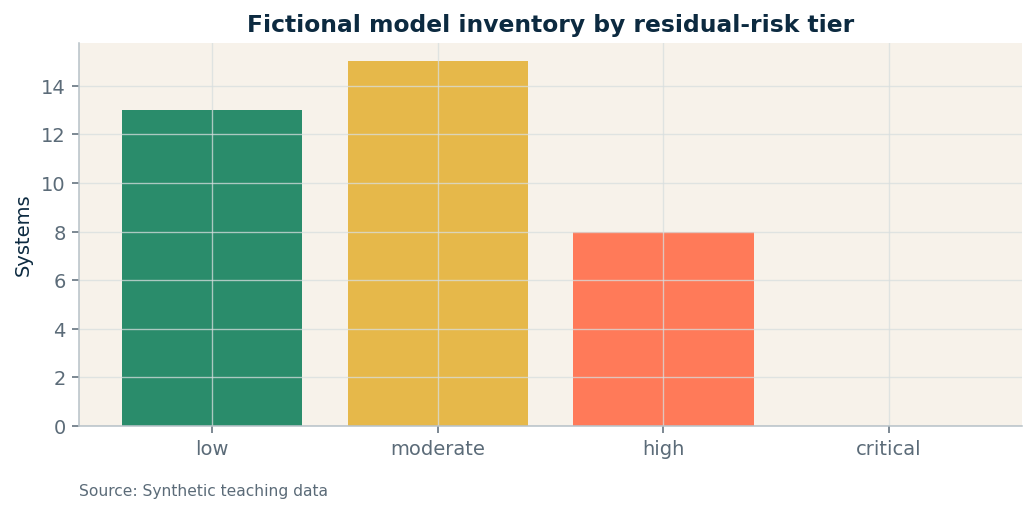

In [4]:
tier_counts = inventory["risk_tier"].value_counts().reindex(["low", "moderate", "high", "critical"], fill_value=0)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar(
    tier_counts.index,
    tier_counts.values,
    color=[COLORS["green"], COLORS["gold"], COLORS["coral"], COLORS["red"]],
)
ax.set(title="Fictional model inventory by residual-risk tier", ylabel="Systems")
finish(ax)
plt.tight_layout()


## 2. Group-level AML audit

`cross_border` is used as an operational slice, not as a protected-class proxy. A real
fairness review needs legally and institutionally appropriate groups, documented purpose,
privacy controls, and domain review.


In [5]:
transactions = pd.read_csv(ROOT / "data" / "transactions.csv", parse_dates=["timestamp"])
transactions = transactions.sort_values("timestamp")
features = [
    "amount_usd",
    "cross_border",
    "new_beneficiary",
    "cash_equivalent",
    "country_risk",
    "velocity_24h",
    "night_transaction",
]
split = chronological_split(
    transactions["timestamp"],
    train_fraction=0.65,
    validation_fraction=0.10,
)
train = transactions.iloc[split.train]
validation = transactions.iloc[split.validation]
test = transactions.iloc[split.test]
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=1111),
)
model.fit(train[features], train["investigation_label"])
validation_score = model.predict_proba(validation[features])[:, 1]
threshold_search = []
for candidate in np.linspace(0.05, 0.95, 91):
    prediction = (validation_score >= candidate).astype(int)
    threshold_search.append(
        {
            "threshold": candidate,
            "recall": (
                ((prediction == 1) & (validation["investigation_label"] == 1)).sum()
                / max((validation["investigation_label"] == 1).sum(), 1)
            ),
            "alert_rate": prediction.mean(),
        }
    )
threshold_search = pd.DataFrame(threshold_search)
within_capacity = threshold_search[threshold_search["alert_rate"] <= 0.15]
if within_capacity.empty:
    raise RuntimeError("No validation threshold satisfies the alert-capacity budget")
selected_threshold = float(
    within_capacity.sort_values(
        ["recall", "threshold"],
        ascending=[False, False],
    ).iloc[0]["threshold"]
)
test = test.copy()
test["score"] = model.predict_proba(test[features])[:, 1]
test["prediction"] = (test["score"] >= selected_threshold).astype(int)

def error_rates(group: pd.DataFrame) -> pd.Series:
    tn, fp, fn, tp = confusion_matrix(
        group["investigation_label"], group["prediction"], labels=[0, 1]
    ).ravel()
    _, tpr_low, tpr_high = proportion_interval(tp, tp + fn)
    _, fpr_low, fpr_high = proportion_interval(fp, fp + tn)
    return pd.Series(
        {
            "n": len(group),
            "tpr": tp / max(tp + fn, 1),
            "tpr_low": tpr_low,
            "tpr_high": tpr_high,
            "fpr": fp / max(fp + tn, 1),
            "fpr_low": fpr_low,
            "fpr_high": fpr_high,
            "precision": tp / max(tp + fp, 1),
            "alert_rate": (tp + fp) / len(group),
        }
    )

group_audit = pd.DataFrame(
    {group_value: error_rates(group) for group_value, group in test.groupby("cross_border")}
).T
group_audit.index = ["domestic", "cross_border"]
group_audit.round(3)


,n,tpr,tpr_low,tpr_high,fpr,fpr_low,fpr_high,precision,alert_rate
domestic,300.0,0.857,0.487,0.974,0.034,0.019,0.062,0.375,0.053
cross_border,100.0,0.727,0.434,0.903,0.180,0.114,0.272,0.333,0.240


## 3. Governance KPIs and release gate


In [6]:
tpr_gap = float(group_audit["tpr"].max() - group_audit["tpr"].min())
fpr_gap = float(group_audit["fpr"].max() - group_audit["fpr"].min())
tpr_gap_upper = float(group_audit["tpr_high"].max() - group_audit["tpr_low"].min())
fpr_gap_upper = float(group_audit["fpr_high"].max() - group_audit["fpr_low"].min())
kpis = {
    "owner_coverage": float(inventory["owner_assigned"].mean()),
    "validation_current_rate": float((~inventory["validation_overdue"]).mean()),
    "critical_system_count": int((inventory["risk_tier"] == "critical").sum()),
    "tpr_gap": tpr_gap,
    "fpr_gap": fpr_gap,
    "tpr_gap_conservative_95": tpr_gap_upper,
    "fpr_gap_conservative_95": fpr_gap_upper,
    "validation_selected_threshold": selected_threshold,
}
checks = {
    "owner_coverage": kpis["owner_coverage"] >= 0.95,
    "validation_current_rate": kpis["validation_current_rate"] >= 0.80,
    "no_unowned_critical_system": not (
        (inventory["risk_tier"] == "critical") & (~inventory["owner_assigned"])
    ).any(),
    "tpr_gap": kpis["tpr_gap_conservative_95"] <= 0.15,
    "fpr_gap": kpis["fpr_gap_conservative_95"] <= 0.15,
}
governance_status = "PASS" if all(checks.values()) else "HOLD"
pd.DataFrame(
    {
        "metric_or_control": list(checks),
        "pass": list(checks.values()),
    }
)


,metric_or_control,pass
0,owner_coverage,False
1,validation_current_rate,False
2,no_unowned_critical_system,True
3,tpr_gap,False
4,fpr_gap,False


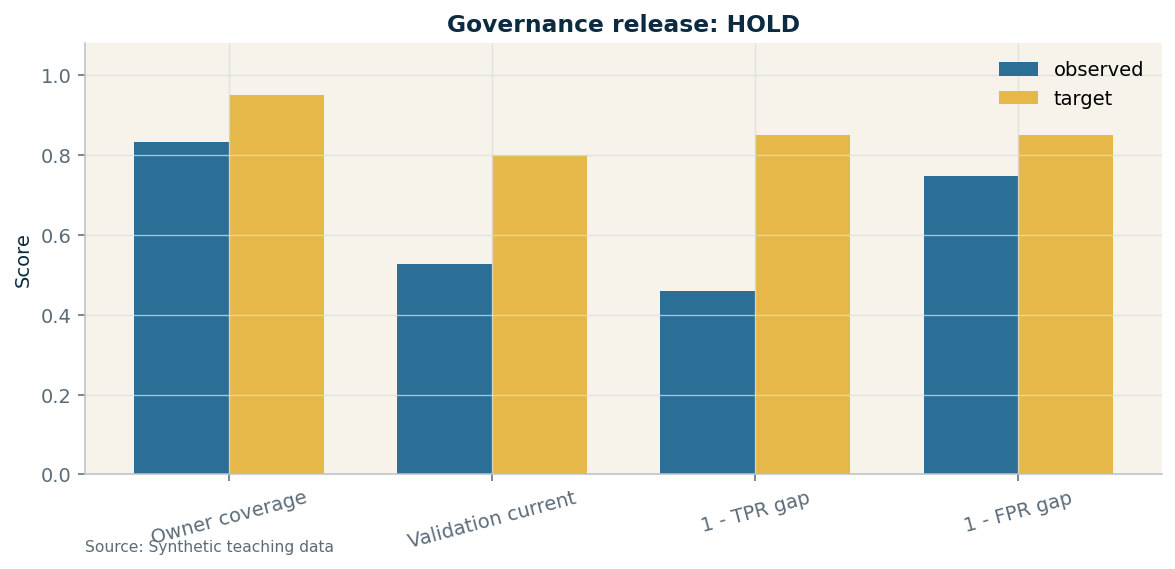

In [7]:
dashboard = pd.DataFrame(
    {
        "KPI": ["Owner coverage", "Validation current", "1 - TPR gap", "1 - FPR gap"],
        "value": [
            kpis["owner_coverage"],
            kpis["validation_current_rate"],
            1 - kpis["tpr_gap_conservative_95"],
            1 - kpis["fpr_gap_conservative_95"],
        ],
        "target": [0.95, 0.80, 0.85, 0.85],
    }
)
fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(len(dashboard))
ax.bar(x - 0.18, dashboard["value"], width=0.36, label="observed", color=COLORS["blue"])
ax.bar(x + 0.18, dashboard["target"], width=0.36, label="target", color=COLORS["gold"])
ax.set_xticks(x, dashboard["KPI"], rotation=15)
ax.set(title=f"Governance release: {governance_status}", ylabel="Score", ylim=(0, 1.08))
ax.legend()
finish(ax)
plt.tight_layout()


## 4. Named remediation plan


In [8]:
remediation = []
if not checks["owner_coverage"]:
    remediation.append(("Model Risk", "Assign owners to every unowned system", "30 days"))
if not checks["validation_current_rate"]:
    remediation.append(("Independent Validation", "Revalidate overdue high-priority systems", "45 days"))
if not checks["no_unowned_critical_system"]:
    remediation.append(("Executive Risk Owner", "Suspend or assign accountable owner to critical systems", "5 days"))
if not checks["tpr_gap"] or not checks["fpr_gap"]:
    remediation.append(("AML Model Owner", "Investigate group error-rate gaps and threshold effects", "30 days"))
remediation = pd.DataFrame(remediation, columns=["owner", "action", "due"])
remediation


,owner,action,due
0,Model Risk,Assign owners to every unowned system,30 days
1,Independent Validation,Revalidate overdue high-priority systems,45 days
2,AML Model Owner,Investigate group error-rate gaps and threshold effects,30 days


## 5. Governance packet


In [9]:
packet = {
    "inventory_snapshot": "fictional-2026-07-28",
    "status": governance_status,
    "kpis": kpis,
    "checks": checks,
    "priority_system_ids": queue["system_id"].tolist(),
    "remediation_count": len(remediation),
}
packet["fingerprint"] = canonical_hash(packet)
packet


{'checks': {'fpr_gap': False,
            'no_unowned_critical_system': True,
            'owner_coverage': False,
            'tpr_gap': False,
            'validation_current_rate': False},
 'fingerprint': '1f351b2f3fbb30113953117e216be261a1f518621a21d4c792e4d3eebf168a5e',
 'inventory_snapshot': 'fictional-2026-07-28',
 'kpis': {'critical_system_count': 0,
          'fpr_gap': 0.1456455880661119,
          'fpr_gap_conservative_95': 0.25360890374716605,
          'owner_coverage': 0.8333333333333334,
          'tpr_gap': 0.1298701298701298,
          'tpr_gap_conservative_95': 0.5399656768313856,
          'validation_current_rate': 0.5277777777777778,
          'validation_selected_threshold': 0.6399999999999999},
 'priority_system_ids': ['sys-007',
                         'sys-014',
                         'sys-011',
                         'sys-031',
                         'sys-017',
                         'sys-027',
                         'sys-035',
                     

## Takeaways

- Governance requires ownership, thresholds, evidence, and due dates.
- Residual risk combines model behavior with deployment impact and control strength.
- Aggregate accuracy can hide material group-level error differences.
- Small group slices need intervals; conservative gap bounds can hold a release even
  when point estimates look acceptable.
- A `HOLD` decision is useful only when it creates a specific remediation queue.

**Challenge:** add incident severity and vendor concentration, then recompute priority
under a fixed validation-team capacity.
